Chapter 32
# kNN分类
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

决策边界 (decision boundary) 是分类模型在特征空间中划分不同类别的分界线或边界。


通
俗地说，决策边界就像是一道看不见的墙，把不同类别的数据点分隔开。
对于鸢尾花数据集，决策边界就是将 setosa ●、versicolor ●、virginica ● 这三类点“尽
可能准确地”区分开的线或曲线。


大家会在本章中看到，为了获得不同算法的决策边界，我们一般会用 numpy.meshgrid() 生成
一系列均匀网格数据，然后再分别预测每个网格点的分类，以此划定决策边界。
在简单的情况下，决策边界可能是一条直线；但在复杂的问题中，决策边界可能是一条弯曲的曲
线，甚至是多维空间中的超平面。



模型训练过程就是调整模型的参数，使得决策边界能够最好地拟合训练数据，并且在未见过的数据
上也能表现良好。


要注意的是，决策边界的好坏直接影响分类模型的性能。一个良好的决策边界能够很好地将数据分
类，而一个不合适的决策边界可能导致模型预测错误。因此，选择合适的分类算法和调整模型参数是非
常重要的，以获得有效的决策边界和准确的分类结果

##k 最近邻分类 (k-nearest neighbors)，简称 kNN。


本书前文提过，kNN 思路很简单——“近朱者赤，近墨者黑”。更准确地说，小范围投票，少数服从多
数 (majority rule)，如图 2 所示。k 是参与投票的最近邻的数量，k 为用户输入值。


最近邻数量 k 直接影响查询点分类结果；因此，选取合适 k 值格外重要。

图 3 所示为 k 取四个不同值时，查询点 × 预测分类结果变化情况。如图 3 (a) 所示，当 k =
4 时，查询点 × 近邻中，3 个近邻为 ● (C1)，1 个近邻为 ● (C2)；采用等权重投票，查询点 ×
预测分类为● (C1)。


当近邻数量 k 提高到 8 时，近邻社区中，4 个近邻为 ● (C1)，4 个近邻为 ● (C2)，如图 3 (b)
所示；等权重投票的话，两个标签各占 50%。因此 k = 8 时，查询点 × 恰好在决策边界上。

如图 3 (c) 所示，当 k = 12 时，查询点 × 近邻中 5 个为 ● (C1)，7 个为 ● (C2)；等权
重投票条件下，查询点 × 预测标签为 ● (C2)。当 k = 16 时，如图 3 (c) 所示，查询点 × 预测
标签同样为 ● (C2)。


kNN 算法选取较小的 k 值虽然能准确捕捉训练数据的分类模式；但是，缺点也很明显，容易受到噪
声影响。


数据可能不足；意外性比较大；判断条件较严格；类似 水满则溢

## 图像

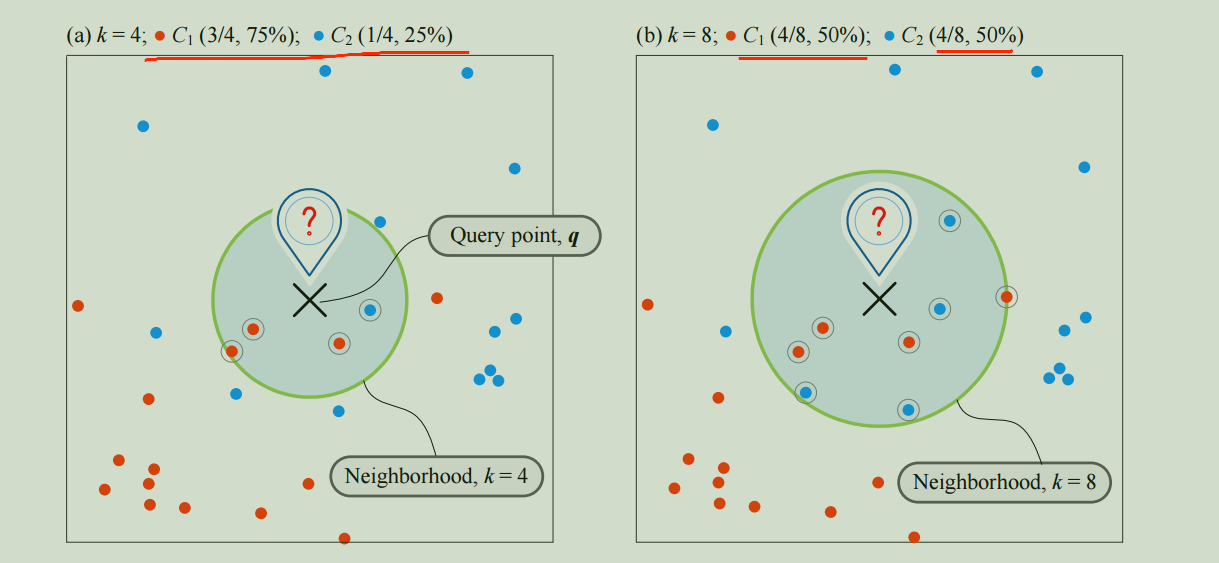

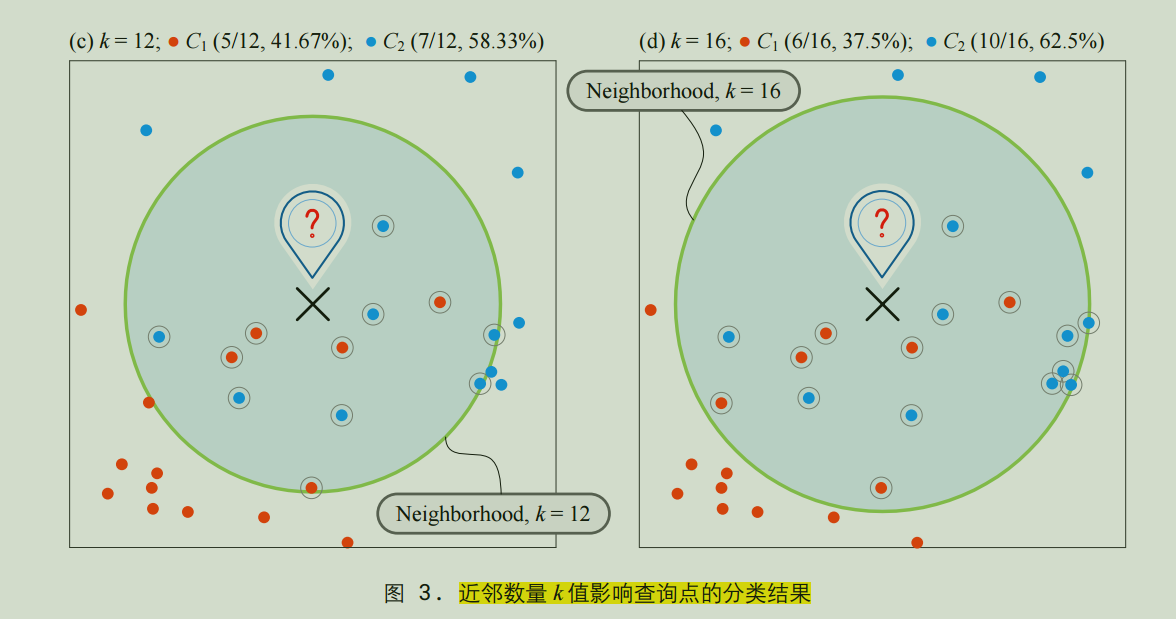

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap #创建离散色谱，即颜色映射，展示鸢尾花预测分类的区域。
from sklearn import neighbors, datasets #kNN-k临近算法

# 导入并整理数据

In [3]:
# 导入并整理数据
iris = datasets.load_iris()
X = iris.data[:, :2] # 取前两列数据；特征
y = iris.target # 标签也就是种类也就是种类[0,1,2]

In [5]:
X.shape

(150, 2)

In [6]:
X[:5]

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6]])

In [7]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## 生成网格化数据

In [8]:
# 生成网格化数据
x1_array = np.linspace(4,8,101)
x2_array = np.linspace(1,5,101)
xx1, xx2 = np.meshgrid(x1_array,x2_array)

In [9]:
xx1.shape

(101, 101)

### 创建色谱

用 numpy.meshgrid() 生成网格化数据，这些就是用来预测分类的查询点。


用 matplotlib.colors.ListedColormap() 创建离散色谱，即颜色映射，展示鸢尾花预
测分类的区域。

In [10]:
# 创建色谱
# 每一行就是一个rgb
rgb = [[255, 238, 255],
       [219, 238, 244],
       [228, 228, 228]]
rgb = np.array(rgb)/255. # 归一化（0-1）
cmap_light = ListedColormap(rgb) # 创建离散色谱，即颜色映射，展示鸢尾花预测分类的区域。
# 预测区域的颜色；也就是每个区域对应的RGB值
cmap_bold = [[255, 51, 0],
             [0, 153, 255],
             [138,138,138]]
cmap_bold = np.array(cmap_bold)/255. # 归一化

用 sklearn.neighbors.KNeighborsClassifier(k_neighbors) 创建了一个 k 最近邻
分类器对象 kNN，并将 k_neighbors 作为参数传递给这个分类器。这里的 k_neighbors 指定了算法
中要使用的最近邻居数量。

In [11]:
k_neighbors = 4 # 定义kNN近邻数量k
# 创建kNN分类器对象
kNN = neighbors.KNeighborsClassifier(k_neighbors)
kNN.fit(X, y) # 用训练数据训练kNN

KNeighborsClassifier(n_neighbors=4)

## 预测数据

转为一位数组；按照列排列；每行就是一个点

In [12]:
q = np.c_[xx1.ravel(), xx2.ravel()] # （101*101）* 2
print(q.shape)
# 用kNN对一系列查询点进行预测
y_predict = kNN.predict(q) # 预测的数据为 （101*101） （一维数组）二维数组

print(y_predict.shape)
y_predict = y_predict.reshape(xx1.shape) # 将形状转为 101*101
print(y_predict.shape)

(10201, 2)
(10201,)
(101, 101)


In [13]:
y_predict

array([[1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       ...,
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2]])

# 可视化

## 绘制分类区域

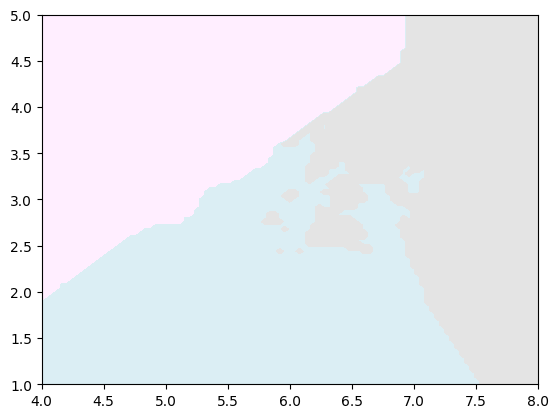

In [14]:
fig, ax = plt.subplots()
# 根据 预测坐标点的标签划分区域
plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)

##绘制分类决策边界

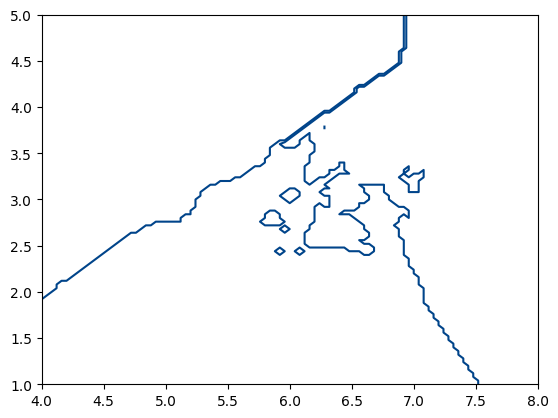

In [16]:
fig, ax = plt.subplots()


#plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
# 绘制决策边界
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],  #分为区域012
            colors=np.array([0, 68, 138])/255.)

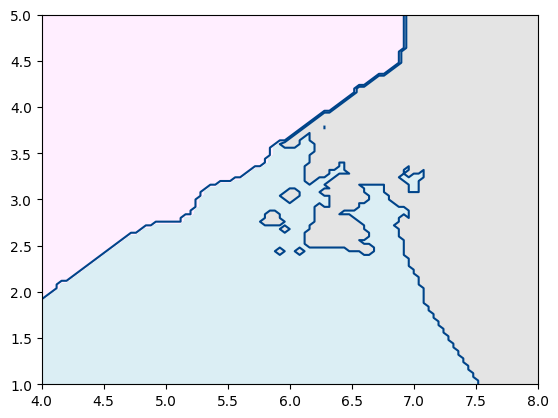

In [17]:
fig, ax = plt.subplots()


plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
# 绘制决策边界
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],  #分为区域012
            colors=np.array([0, 68, 138])/255.)

In [18]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [20]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [19]:
iris.target_names[y]

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [23]:
cmap_bold

array([[1.        , 0.2       , 0.        ],
       [0.        , 0.6       , 1.        ],
       [0.54117647, 0.54117647, 0.54117647]])

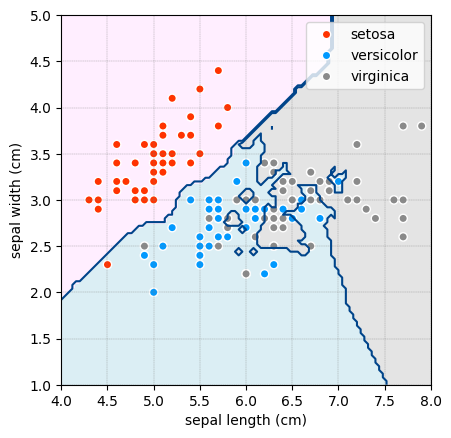

In [21]:
# 可视化
fig, ax = plt.subplots()


plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
            colors=np.array([0, 68, 138])/255.)

# 绘制散点图
sns.scatterplot(x=X[:, 0], y=X[:, 1],
                hue=iris.target_names[y], #按照 'species' 列的值对数据点进行颜色分类
                ax = ax, # 轴对象
                #设置颜色配色方案
                palette=dict(setosa=cmap_bold[0,:],
                versicolor=cmap_bold[1,:],
                virginica=cmap_bold[2,:]),
                alpha=1.0,
                linewidth = 1, edgecolor=[1,1,1]) #边缘为白色
plt.xlim(4, 8); plt.ylim(1, 5) # 范围
plt.xlabel(iris.feature_names[0])  #标签特征名花萼花瓣
plt.ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,  # 网格格式
        color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box') # x,y轴比例一致

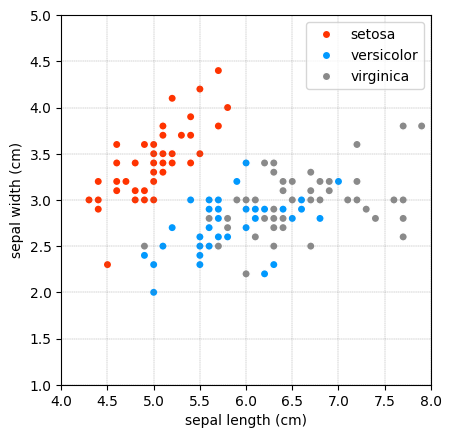

In [22]:
# 可视化
fig, ax = plt.subplots()



# 绘制散点图
sns.scatterplot(x=X[:, 0], y=X[:, 1],
                hue=iris.target_names[y], #按照 'species' 列的值对数据点进行颜色分类
                ax = ax, # 轴对象
                #设置颜色配色方案
                palette=dict(setosa=cmap_bold[0,:],
                versicolor=cmap_bold[1,:],
                virginica=cmap_bold[2,:]),
                alpha=1.0,
                linewidth = 1, edgecolor=[1,1,1]) #边缘为白色
plt.xlim(4, 8); plt.ylim(1, 5) # 范围
plt.xlabel(iris.feature_names[0])  #标签特征名花萼花瓣
plt.ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,  # 网格格式
        color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box') # x,y轴比例一致

# 不同kNN 近邻数量，比如说尝试 6、7、8、9 等等，然后说明 kNN 近邻数量对决策
边界的影响。


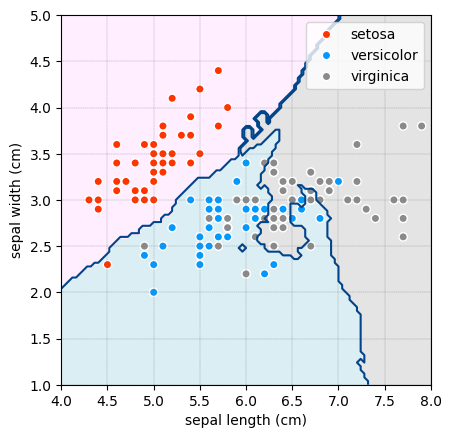

In [24]:
k_neighbors = 6 # 定义kNN近邻数量k
# 创建kNN分类器对象
kNN = neighbors.KNeighborsClassifier(k_neighbors)
kNN.fit(X, y) # 用训练数据训练kNN
q = np.c_[xx1.ravel(), xx2.ravel()]
# 用kNN对一系列查询点进行预测
y_predict = kNN.predict(q)
y_predict = y_predict.reshape(xx1.shape)
# 可视化
fig, ax = plt.subplots()
plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
 colors=np.array([0, 68, 138])/255.)
sns.scatterplot(x=X[:, 0], y=X[:, 1],
    hue=iris.target_names[y],
    ax = ax,
    palette=dict(setosa=cmap_bold[0,:],
    versicolor=cmap_bold[1,:],
    virginica=cmap_bold[2,:]),
    alpha=1.0,
    linewidth = 1, edgecolor=[1,1,1])
plt.xlim(4, 8); plt.ylim(1, 5)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,
 color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box')


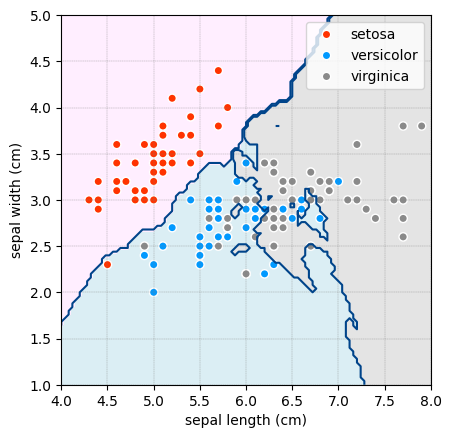

In [26]:
k_neighbors = 7 # 定义kNN近邻数量k
# 创建kNN分类器对象
kNN = neighbors.KNeighborsClassifier(k_neighbors)
kNN.fit(X, y) # 用训练数据训练kNN
q = np.c_[xx1.ravel(), xx2.ravel()]
# 用kNN对一系列查询点进行预测
y_predict = kNN.predict(q)
y_predict = y_predict.reshape(xx1.shape)
# 可视化
fig, ax = plt.subplots()
plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
 colors=np.array([0, 68, 138])/255.)
sns.scatterplot(x=X[:, 0], y=X[:, 1],
    hue=iris.target_names[y],
    ax = ax,
    palette=dict(setosa=cmap_bold[0,:],
    versicolor=cmap_bold[1,:],
    virginica=cmap_bold[2,:]),
    alpha=1.0,
    linewidth = 1, edgecolor=[1,1,1])
plt.xlim(4, 8); plt.ylim(1, 5)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,
 color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box')


In [30]:
def picture(k_neighbors,ax):
    # 创建kNN分类器对象
    kNN = neighbors.KNeighborsClassifier(k_neighbors)
    kNN.fit(X, y) # 用训练数据训练kNN
    q = np.c_[xx1.ravel(), xx2.ravel()]
    # 用kNN对一系列查询点进行预测
    y_predict = kNN.predict(q)
    y_predict = y_predict.reshape(xx1.shape)
    # 可视化
    fig, ax = plt.subplots()
    plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
    plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
    colors=np.array([0, 68, 138])/255.)
    sns.scatterplot(x=X[:, 0], y=X[:, 1],
        hue=iris.target_names[y],
        ax = ax,
        palette=dict(setosa=cmap_bold[0,:],
        versicolor=cmap_bold[1,:],
        virginica=cmap_bold[2,:]),
        alpha=1.0,
        linewidth = 1, edgecolor=[1,1,1])
    plt.xlim(4, 8); plt.ylim(1, 5)
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    ax.grid(linestyle='--', linewidth=0.25,
    color=[0.5,0.5,0.5])
    ax.set_aspect('equal', adjustable='box')


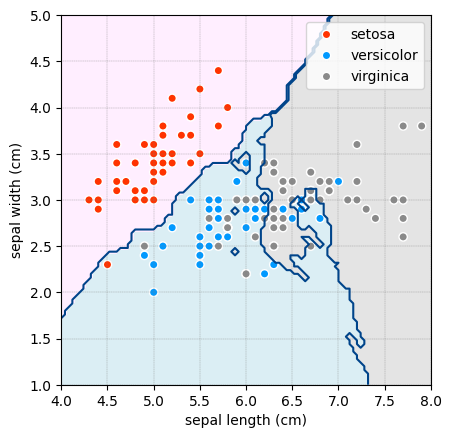

In [28]:
picture(8)



```
fig, ax = plt.subplots(2, 3)

for i in range(4, 10):
    row = (i - 4) // 3  # 计算行索引
    col = (i - 4) % 3   # 计算列索引
    picture(i, ax[row, col])
```



[[<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]]


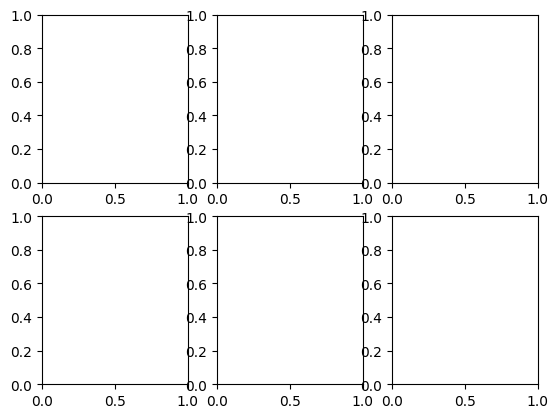

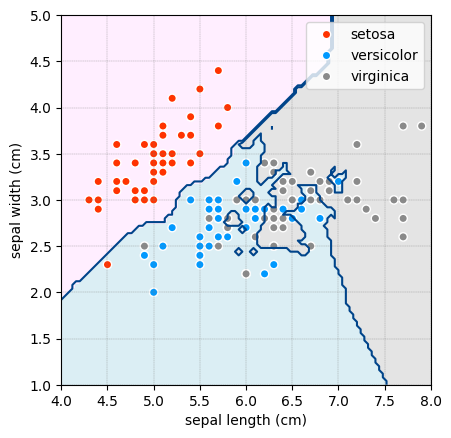

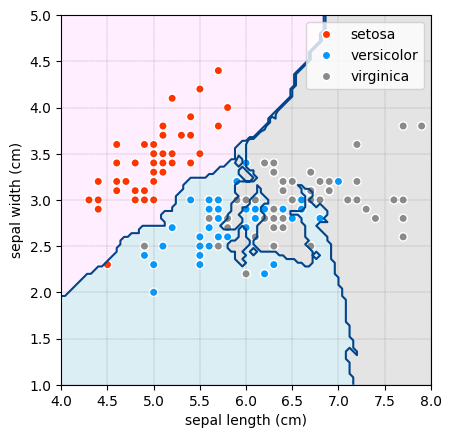

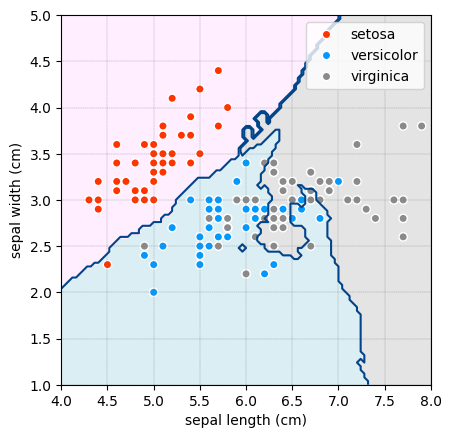

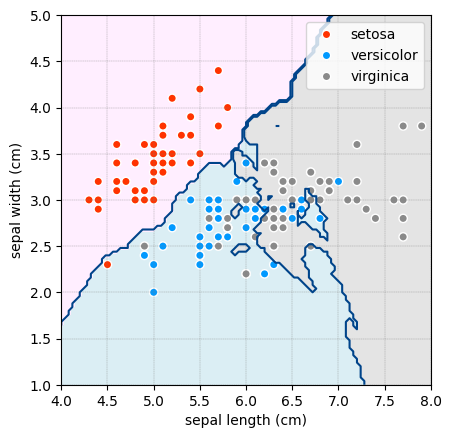

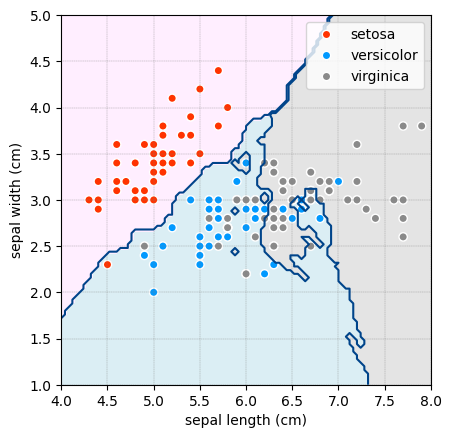

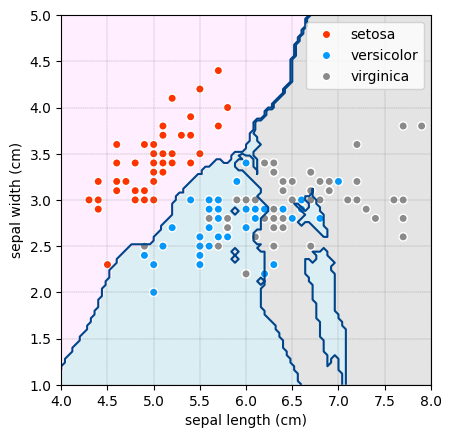

In [33]:
fig, ax = plt.subplots(2, 3)
print(ax)
print(ax.flat)
# 将flat展为一位数组
for i, subplot in zip(range(4, 10), ax.flat):
    picture(i, subplot)

# 重新绘制

In [42]:
def picture(k_neighbors, ax):
    # 创建kNN分类器对象
    kNN = neighbors.KNeighborsClassifier(k_neighbors)
    kNN.fit(X, y)  # 用训练数据训练kNN
    q = np.c_[xx1.ravel(), xx2.ravel()]
    # 用kNN对一系列查询点进行预测
    y_predict = kNN.predict(q)
    y_predict = y_predict.reshape(xx1.shape)

    # 可视化 - 所有 plt.xxx 改为 ax.xxx
    ax.contourf(xx1, xx2, y_predict, cmap=cmap_light)  # plt.contourf → ax.contourf
    ax.contour(xx1, xx2, y_predict, levels=[0,1,2],
               colors=np.array([0, 68, 138])/255.)  # plt.contour → ax.contour

    sns.scatterplot(x=X[:, 0], y=X[:, 1],
                    hue=iris.target_names[y],
                    ax=ax,  # 这个保持不变，已经传入了 ax
                    palette=dict(setosa=cmap_bold[0,:],
                                 versicolor=cmap_bold[1,:],
                                 virginica=cmap_bold[2,:]),
                    alpha=1.0,
                    linewidth=1, edgecolor=[1,1,1])

    # plt.xlim → ax.set_xlim, plt.ylim → ax.set_ylim
    ax.set_xlim(4, 8)
    ax.set_ylim(1, 5)
    ax.set_xlabel(iris.feature_names[0])  # plt.xlabel → ax.set_xlabel
    ax.set_ylabel(iris.feature_names[1])  # plt.ylabel → ax.set_ylabel
    ax.grid(linestyle='--', linewidth=0.25, color=[0.5,0.5,0.5])
    ax.set_aspect('equal', adjustable='box')

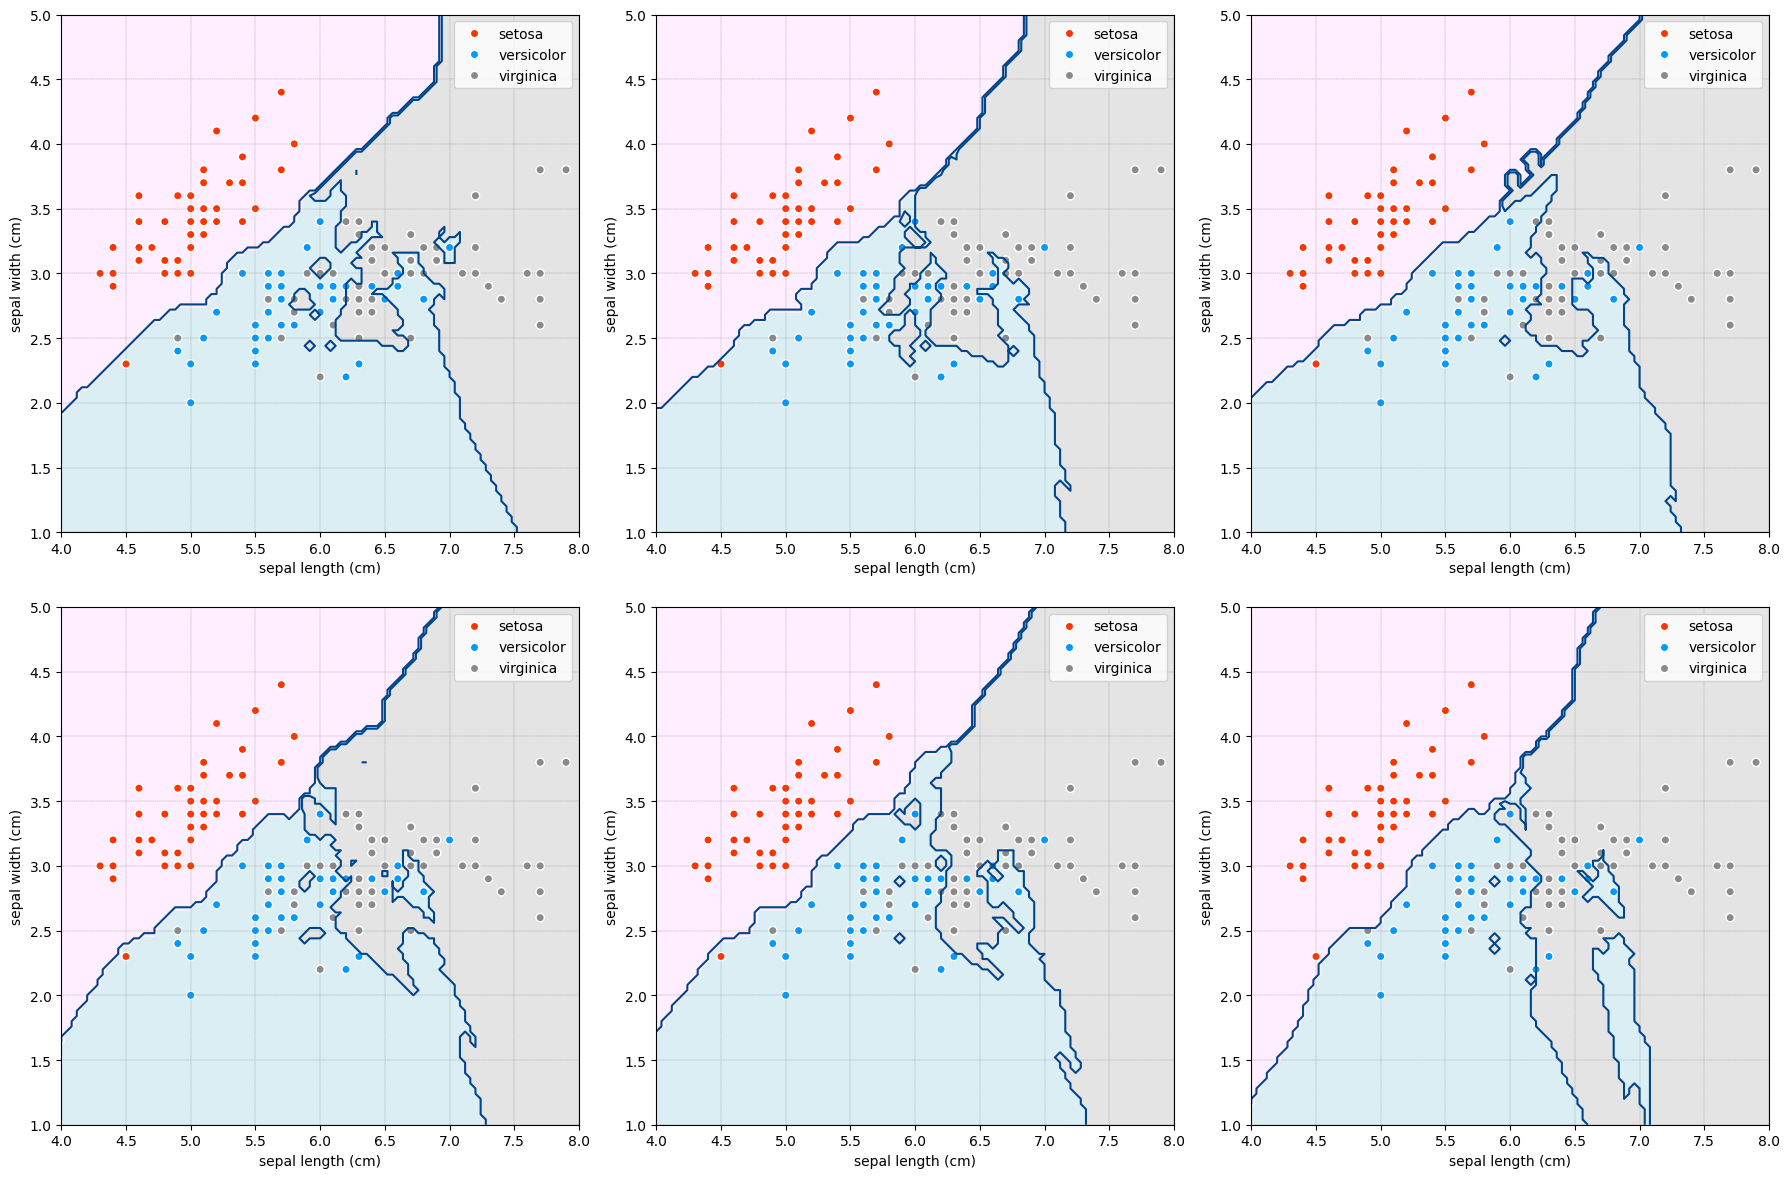

In [44]:
# 将 figsize 调大，例如 (18, 12) 或 (20, 15)
fig, ax = plt.subplots(2, 3, figsize=(18, 12))  # 宽18英寸，高12英寸

for i in range(4, 10):
    row = (i - 4) // 3  # 计算行索引
    col = (i - 4) % 3   # 计算列索引
    picture(i, ax[row, col])
plt.tight_layout()  # 自动调整间距
plt.show()

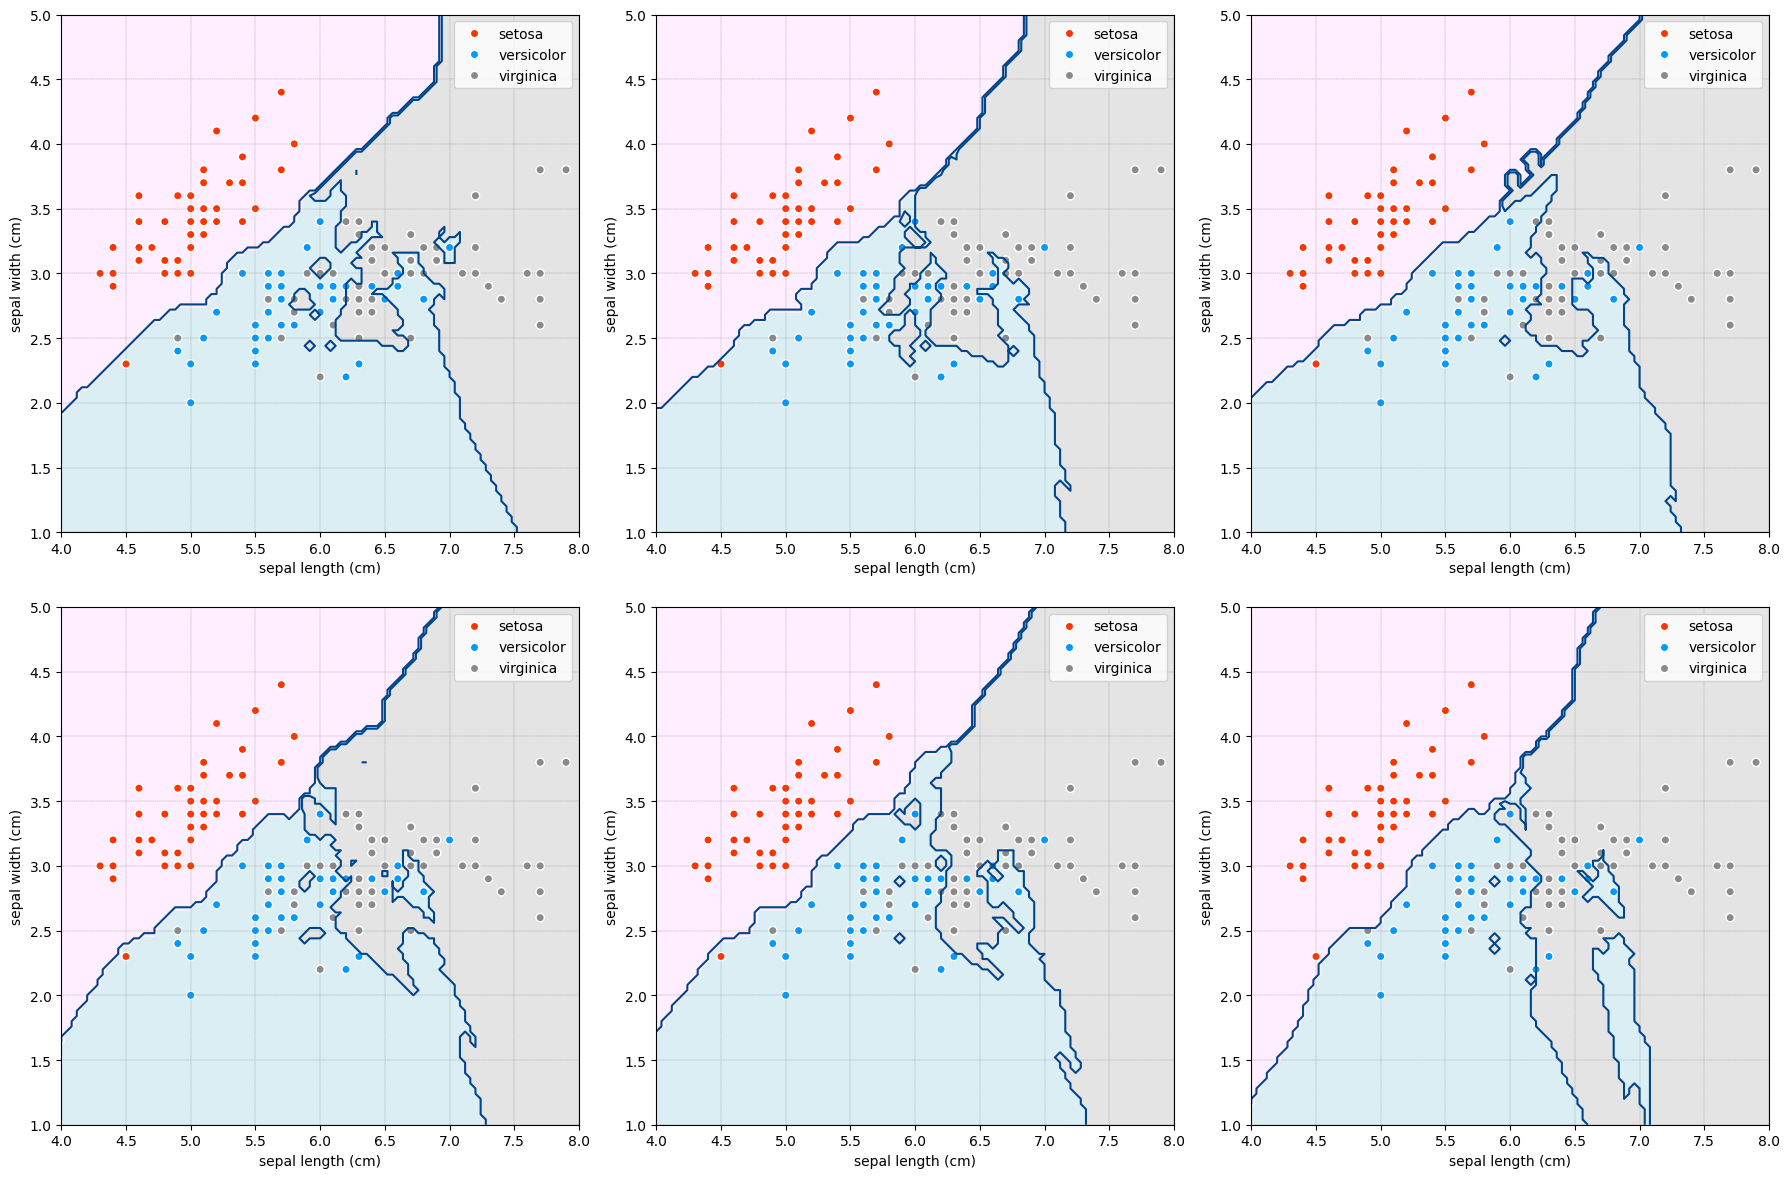

In [45]:
# 将 figsize 调大，例如 (18, 12) 或 (20, 15)
fig, ax = plt.subplots(2, 3, figsize=(18, 12))  # 宽18英寸，高12英寸

for i, subplot in zip(range(4, 10), ax.flat):
    picture(i, subplot)
plt.xlim(4, 8); plt.ylim(1, 5)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.tight_layout()  # 自动调整间距
plt.show()

## K近邻值越大； 越小

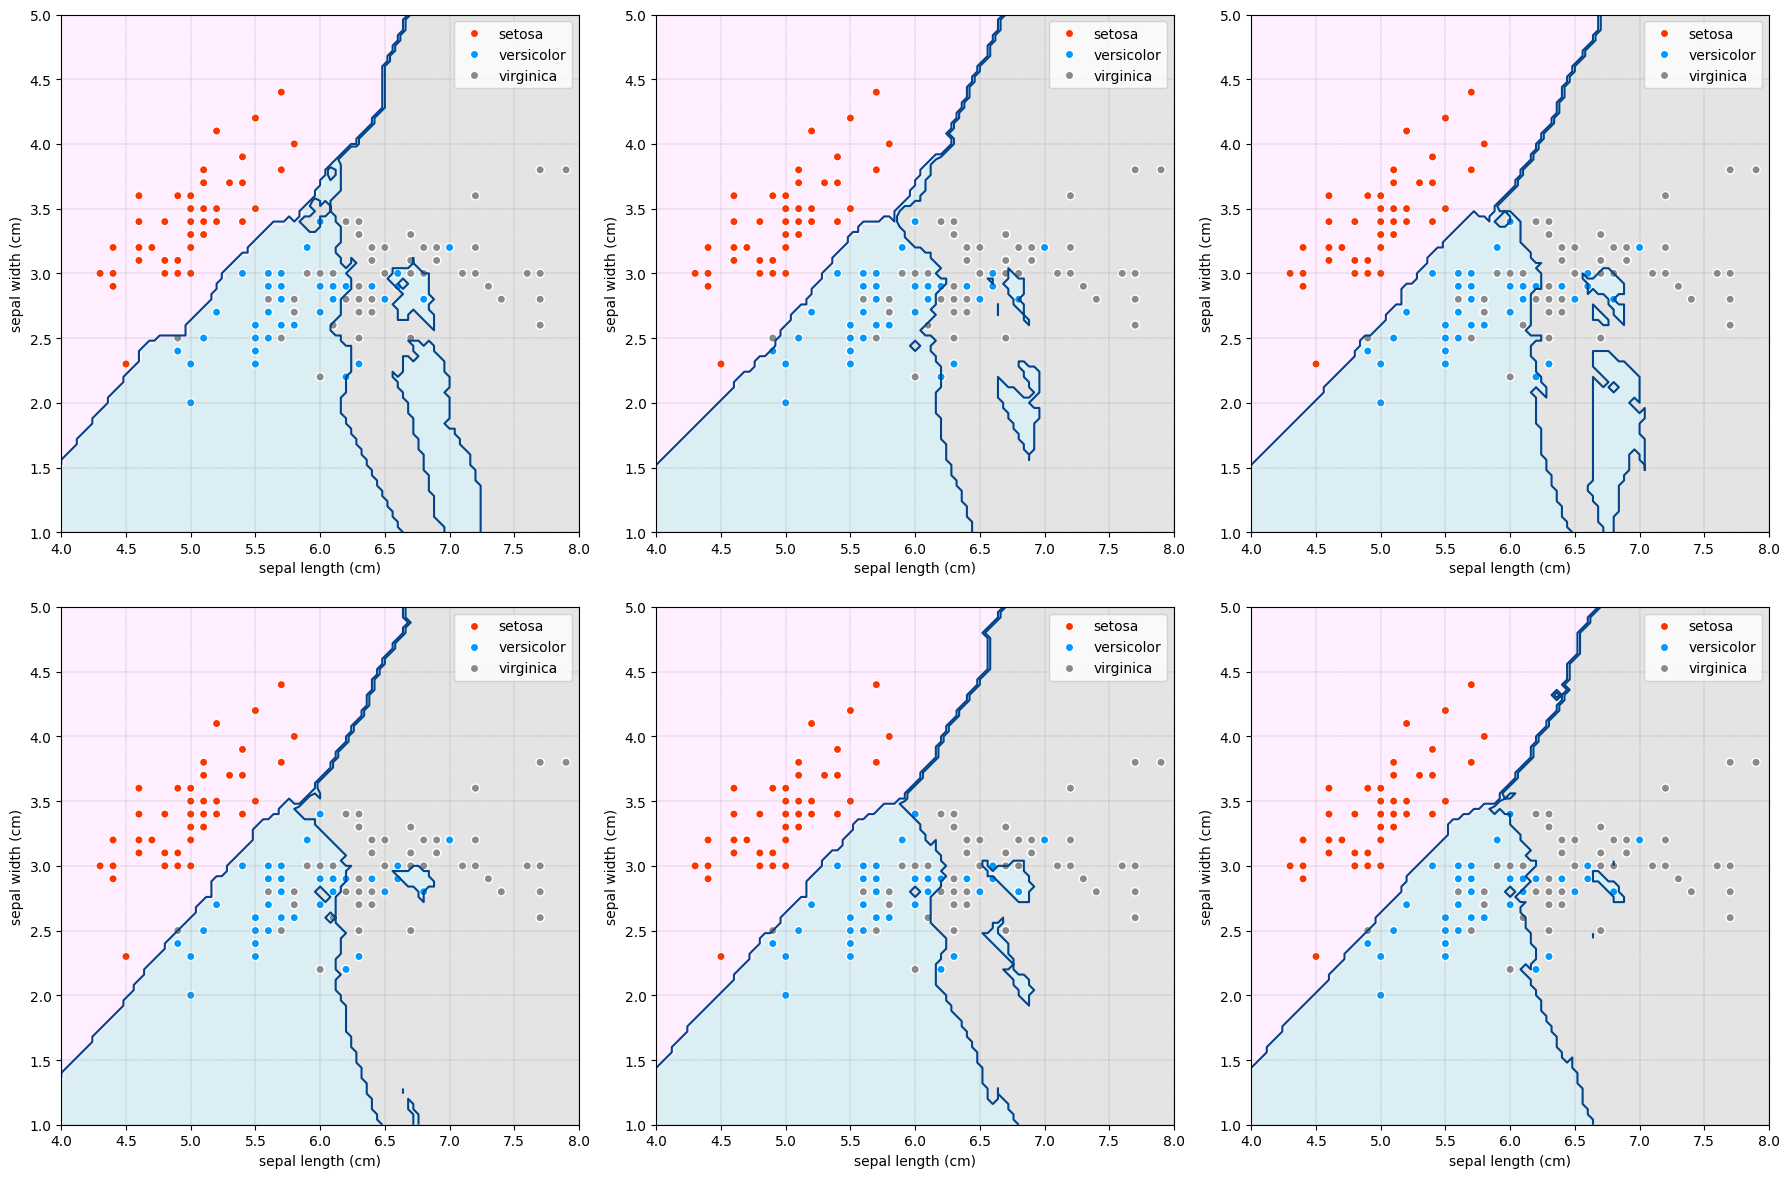

In [46]:
# 将 figsize 调大，例如 (18, 12) 或 (20, 15)
fig, ax = plt.subplots(2, 3, figsize=(18, 12))  # 宽18英寸，高12英寸

for i, subplot in zip(range(10, 16), ax.flat):
    picture(i, subplot)
plt.xlim(4, 8); plt.ylim(1, 5)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.tight_layout()  # 自动调整间距
plt.show()